# Lab 4: EEG Feature Extraction and Classification Using AI
## About Dataset
### Introduction

The database contains EEG recordings of subjects before and during the performance of mental arithmetic tasks.
Method of Recording Signals

The EEGs were recorded monopolarly using Neurocom EEG 23-channel system (Ukraine, XAI-MEDICA). The silver/silver chloride electrodes were placed on the scalp according to the International 10/20 scheme. All electrodes were referenced to the interconnected ear reference electrodes.
A high-pass filter with a 30 Hz cut-off frequency and a power line notch filter (50 Hz) were used. All recordings are artifact-free EEG segments of 60 seconds duration. At the stage of data preprocessing, the Independent Component Analysis (ICA) was used to eliminate the artifacts (eyes, muscle, and cardiac overlapping of the cardiac pulsation). The arithmetic task was the serial subtraction of two numbers. Each trial started with the communication orally 4-digit (minuend) and 2-digit (subtrahend) numbers (e.g. 3141 and 42).
Data Description

The data contains 36 csv files for each subject having 19 channels. It is converted from EDF to csv from the original data source.
The channels selected are Fp1, Fp2, F3, F4, F7, F8, T3,T4, C3, C4, T5, T6, P3, P4, O1, O2, Fz, Cz, Pz. These are the columns in the dataset.
Acknowledgements

### The data is taken from the following resources
https://www.mdpi.com/2306-5729/4/1/14
Goldberger, A., et al. "PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. Circulation [Online]. 101 (23), pp. e215–e220." (2000).

## References
[1] Available online, [https://www.kaggle.com/datasets/amananandrai/complete-eeg-dataset/data](https://www.kaggle.com/datasets/amananandrai/complete-eeg-dataset/data), last accessed: 29/01/2026

## Task1: 
Load and inspect the EEG dataset in ./dataset/, verify file consistency, summarise the structure (number of files, rows, columns, missing values), identify candidate EEG channels, and generate quick visual checks (signal traces and distribution summaries). Output should provide enough information to decide window size, channel selection, and feasible labels/targets for later classification tasks.

Found 36 subject files in: /opt/data/comp40771_lab4/dataset
First 5 files: ['s00.csv', 's01.csv', 's02.csv', 's03.csv', 's04.csv']
Last 5 files: ['s31.csv', 's32.csv', 's33.csv', 's34.csv', 's35.csv']


,subject,rows,cols,numeric_cols,non_numeric_cols,missing_values
0,s00,30999,19,19,0,0
1,s01,30999,19,19,0,0
2,s02,30999,19,19,0,0
3,s03,30999,19,19,0,0
4,s04,30999,19,19,0,0
5,s05,30999,19,19,0,0
6,s06,30999,19,19,0,0
7,s07,30999,19,19,0,0
8,s08,30999,19,19,0,0
9,s09,30999,19,19,0,0


Unique column schemas: 36
- s01:
  Missing vs base: ['-0.080058', '-0.42704', '-0.52398', '-1.144', '-2.5017', '-2.5918', '-2.7403', '-3.3238', '-3.7614', '-7.0917']...
  Extra vs base: ['10.047', '10.398', '10.55', '11.392', '13.829', '13.902', '13.99', '14.146', '14.289', '14.455']...
- s02:
  Missing vs base: ['-0.080058', '-0.42704', '-0.52398', '-1.144', '-2.5017', '-2.5918', '-2.7403', '-3.3238', '-3.7614', '-7.0917']...
  Extra vs base: ['-0.76166', '-10.463', '-2.2799', '-2.9565', '0.71455', '0.87979', '0.92747', '0.99729', '1.5571', '1.756']...
- s03:
  Missing vs base: ['-0.080058', '-0.42704', '-0.52398', '-1.144', '-2.5017', '-2.5918', '-2.7403', '-3.3238', '-3.7614', '-7.0917']...
  Extra vs base: ['-0.8904', '-0.91903', '-1.9887', '-3.1273', '0.23331', '0.66792', '0.73461', '0.81788', '0.87061', '0.87688']...
- s04:
  Missing vs base: ['-0.080058', '-0.42704', '-0.52398', '-1.144', '-2.5017', '-2.5918', '-2.7403', '-3.3238', '-3.7614', '-7.0917']...
  Extra vs base: ['-12

,4.476,-2.7403,-2.5017,0.095121,-7.0917,-0.42704,-2.5918,-3.3238,0.9995,0.87011,-0.080058,2.8075,-0.52398,1.9341,-3.7614,-1.144,0.033687,2.7164,0.84831
0,1.2080,-3.3088,-4.4178,-0.52935,-8.5782,0.40699,-3.0996,-3.6005,-0.048363,-0.17258,-0.129650,3.2872,-1.0667,1.53570,-5.1933,-2.2263,-0.68218,4.8287,0.45261
1,-2.5460,-3.7083,-6.4109,-1.00330,-10.2200,1.87700,-3.6952,-3.8673,-1.132300,-1.32850,-0.094006,3.9756,-1.6743,1.12850,-6.5565,-3.0953,-1.28440,6.6513,-0.10393
2,-6.1871,-3.6804,-8.0297,-1.10310,-11.7210,4.01570,-4.2652,-4.0530,-1.984100,-2.36070,0.076473,4.8331,-2.2293,0.79364,-7.4787,-3.4209,-1.54090,7.6371,-0.74250
3,-9.1110,-3.0027,-8.8444,-0.65140,-12.7840,6.71770,-4.6708,-4.0965,-2.337200,-3.02550,0.401930,5.7805,-2.6145,0.58741,-7.6430,-2.9829,-1.24870,7.4512,-1.32640
4,-10.8820,-1.5795,-8.5962,0.41845,-13.1950,9.74310,-4.7778,-3.9759,-2.021600,-3.15980,0.869980,6.7141,-2.7528,0.50809,-6.9019,-1.7585,-0.31857,6.1410,-1.69630


Candidate EEG channels (numeric, excluding metadata-like names): 19
['4.476', '-2.7403', '-2.5017', '0.095121', '-7.0917', '-0.42704', '-2.5918', '-3.3238', '0.9995', '0.87011', '-0.080058', '2.8075', '-0.52398', '1.9341', '-3.7614', '-1.144', '0.033687', '2.7164', '0.84831'] 


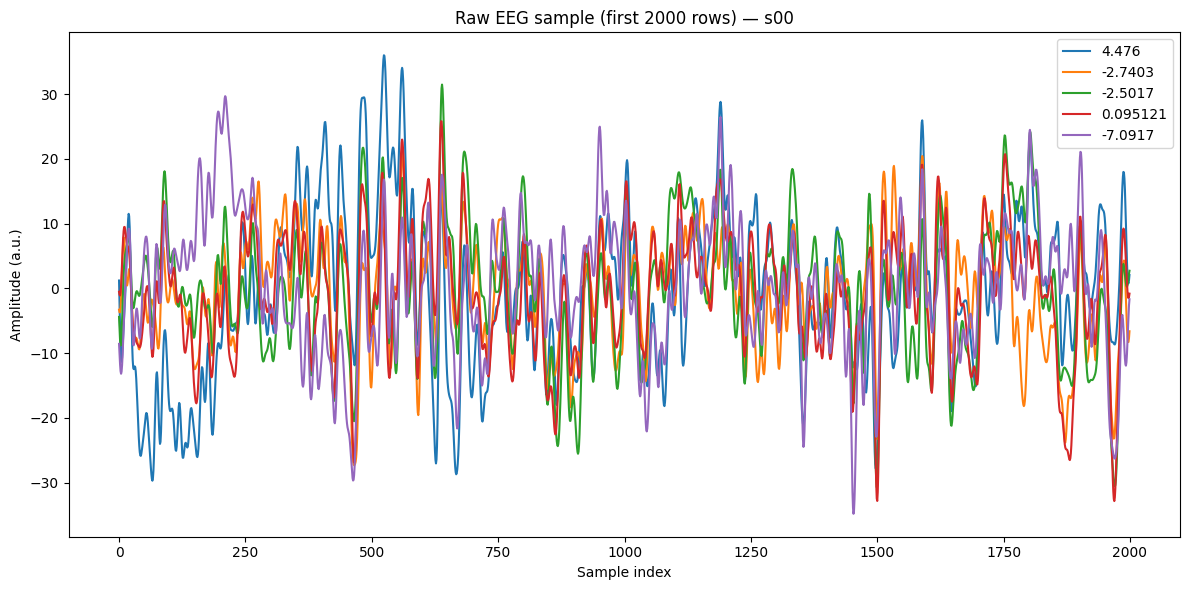

,count,mean,std,min,1%,5%,50%,95%,99%,max
4.476,30999.0,-0.191957,16.130553,-93.347,-42.44512,-26.1965,-0.000414,25.1565,36.48126,78.811
-2.7403,30999.0,-0.302683,12.409824,-82.339,-33.27854,-19.5492,0.008535,18.7527,29.36116,47.909
-2.5017,30999.0,-0.209628,12.941858,-68.406,-32.66300,-21.1561,0.000025,20.5535,31.08698,46.165
0.095121,30999.0,-0.137932,12.318097,-58.415,-30.66710,-20.4976,0.000023,19.9532,28.59430,45.455
-7.0917,30999.0,-0.184192,12.982267,-74.958,-32.88676,-21.0680,-0.001488,20.6432,29.33938,48.981


,subject,n_channels,median_mad,median_std
0,s00,19,7.904177,12.386409
1,s01,19,7.954340,12.670441
2,s02,19,7.053089,10.774589
3,s03,19,5.428894,8.557456
4,s04,19,8.529440,13.102032
5,s05,19,6.950993,10.572532
6,s06,19,4.450790,6.909504
7,s07,19,6.433270,10.467030
8,s08,19,4.770803,7.594021
9,s09,19,5.705841,9.180371



Next step suggestion:
- Decide on a window length (e.g., 1–2 seconds worth of samples) once the sampling rate or time column is confirmed.
- Confirm whether a label/target column exists; if absent, define a proxy task (e.g., subject ID classification or anomaly detection).


In [1]:
import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("dataset")

def list_dataset_files(data_dir: Path) -> list[Path]:
    files = sorted(data_dir.glob("s*.csv"))
    if not files:
        raise FileNotFoundError(
            f"No CSV files found in {data_dir.resolve()}. "
            "Expected files named like s00.csv ... s35.csv."
        )
    return files

def read_csv_safely(path: Path) -> pd.DataFrame:
    # Robust read: handle common CSV quirks without being overly permissive
    try:
        df = pd.read_csv(path)
    except Exception as e:
        raise RuntimeError(f"Failed to read {path.name}: {e}") from e
    if df.empty:
        raise ValueError(f"{path.name} loaded but contains no rows.")
    return df

def summarise_dataframe(df: pd.DataFrame) -> dict:
    n_rows, n_cols = df.shape
    missing = int(df.isna().sum().sum())
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    non_numeric_cols = [c for c in df.columns if c not in numeric_cols]
    return {
        "rows": n_rows,
        "cols": n_cols,
        "missing_values": missing,
        "numeric_cols": len(numeric_cols),
        "non_numeric_cols": len(non_numeric_cols),
        "columns": df.columns.tolist(),
    }

def infer_channel_columns(df: pd.DataFrame) -> list[str]:
    """
    Heuristic: treat numeric columns as candidate EEG channels, excluding
    typical metadata names if present.
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    exclude = {"time", "timestamp", "ts", "label", "class", "event", "subject", "id"}
    channels = [c for c in numeric_cols if c.strip().lower() not in exclude]
    return channels

# 1) Verify directory structure and list files
files = list_dataset_files(DATA_DIR)
print(f"Found {len(files)} subject files in: {DATA_DIR.resolve()}")
print("First 5 files:", [f.name for f in files[:5]])
print("Last 5 files:", [f.name for f in files[-5:]])

# 2) Load all files and collect structural checks
summaries = []
dataframes = {}

for f in files:
    df = read_csv_safely(f)
    dataframes[f.stem] = df
    s = summarise_dataframe(df)
    s["file"] = f.name
    s["subject"] = f.stem
    summaries.append(s)

summary_df = pd.DataFrame(summaries).sort_values("subject")
display(summary_df[["subject", "rows", "cols", "numeric_cols", "non_numeric_cols", "missing_values"]])

# 3) Check schema consistency across subjects
all_columns = summary_df["columns"].tolist()
unique_schemas = {tuple(cols) for cols in all_columns}
print(f"Unique column schemas: {len(unique_schemas)}")

if len(unique_schemas) > 1:
    print("Warning: column sets differ across files. Showing mismatches:")
    # Compare each schema to the first one
    base = set(all_columns[0])
    for i, cols in enumerate(all_columns[1:], start=1):
        cur = set(cols)
        if cur != base:
            only_in_base = sorted(list(base - cur))
            only_in_cur = sorted(list(cur - base))
            print(f"- {summary_df.iloc[i]['subject']}:")
            if only_in_base:
                print(f"  Missing vs base: {only_in_base[:10]}{'...' if len(only_in_base) > 10 else ''}")
            if only_in_cur:
                print(f"  Extra vs base: {only_in_cur[:10]}{'...' if len(only_in_cur) > 10 else ''}")

# 4) Inspect one example subject in detail
example_subject = summary_df.iloc[0]["subject"]
df0 = dataframes[example_subject]
print(f"\nExample subject: {example_subject}  shape={df0.shape}")
display(df0.head())

channels = infer_channel_columns(df0)
print(f"Candidate EEG channels (numeric, excluding metadata-like names): {len(channels)}")
print(channels[:25], "..." if len(channels) > 25 else "")

# 5) Quick visual sanity check: plot a short segment from a few channels
# Select up to 5 channels to plot
plot_channels = channels[:5] if channels else df0.select_dtypes(include=[np.number]).columns.tolist()[:5]

if not plot_channels:
    raise ValueError("No numeric columns found to plot. Check CSV content and dtypes.")

n_samples = min(2000, len(df0))
x = np.arange(n_samples)

plt.figure(figsize=(12, 6))
for c in plot_channels:
    plt.plot(x, df0[c].values[:n_samples], label=c)
plt.title(f"Raw EEG sample (first {n_samples} rows) — {example_subject}")
plt.xlabel("Sample index")
plt.ylabel("Amplitude (a.u.)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# 6) Basic distribution summary for selected channels
desc = df0[plot_channels].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
display(desc)

# 7) Optional: compute simple per-subject signal scale summary (helps later normalisation choices)
scale_rows = []
for subj, df in dataframes.items():
    ch = infer_channel_columns(df)
    if not ch:
        continue
    # Robust scale estimate: median absolute deviation (MAD) per channel, then median across channels
    vals = df[ch].select_dtypes(include=[np.number]).values
    med = np.nanmedian(vals, axis=0)
    mad = np.nanmedian(np.abs(vals - med), axis=0)
    scale_rows.append({
        "subject": subj,
        "n_channels": len(ch),
        "median_mad": float(np.nanmedian(mad)),
        "median_std": float(np.nanmedian(np.nanstd(vals, axis=0))),
    })

scale_df = pd.DataFrame(scale_rows).sort_values("subject")
display(scale_df.head(10))

print("\nNext step suggestion:")
print("- Decide on a window length (e.g., 1–2 seconds worth of samples) once the sampling rate or time column is confirmed.")
print("- Confirm whether a label/target column exists; if absent, define a proxy task (e.g., subject ID classification or anomaly detection).")


## Task 2 – EEG Pre-processing

In this task, you will implement fundamental EEG pre-processing steps to improve signal quality prior to feature extraction and classification. You will apply temporal filtering to retain physiologically meaningful frequency content, suppress power-line interference, and segment continuous EEG signals into fixed-length windows suitable for machine learning.

## Specifically, you will:

* Apply a band-pass filter to retain EEG activity in the 1–40 Hz range.
* Apply a notch filter to attenuate power-line interference (50 Hz).
* Perform segmentation of continuous EEG into fixed-length windows (e.g. 1 second).
* Visually compare raw and filtered signals to assess noise suppression effects.
The outcome of this task is a set of clean, windowed EEG segments ready for feature extraction.

Subject: s00
EEG shape (samples × channels): (30999, 19)


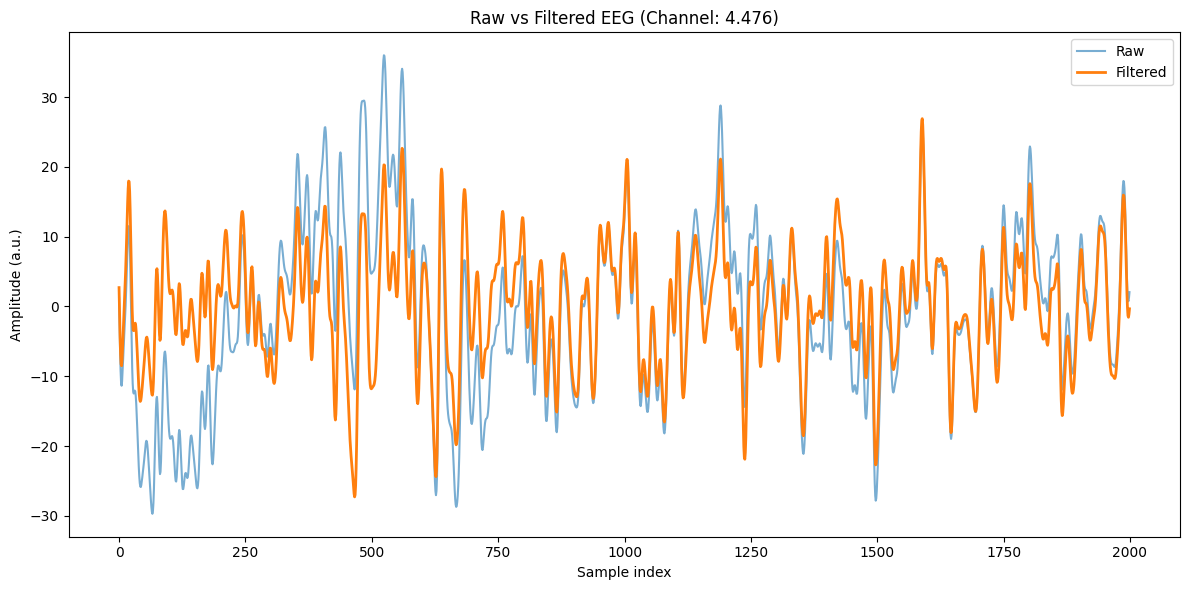

Window length (samples): 256
Number of windows: 121
Segmented EEG shape: (121, 256, 19)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch

# -----------------------------
# Configuration parameters
# -----------------------------
FS = 256        # Sampling frequency (Hz) – adjust if known to differ
LOWCUT = 1.0    # Band-pass lower cutoff (Hz)
HIGHCUT = 40.0  # Band-pass upper cutoff (Hz)
NOTCH_FREQ = 50.0  # Power-line frequency (Hz)
Q_FACTOR = 30.0    # Notch filter quality factor
WINDOW_SEC = 1.0   # Window length in seconds

# -----------------------------
# Filter design functions
# -----------------------------
def bandpass_filter(data, fs, lowcut, highcut, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, data, axis=0)

def notch_filter(data, fs, freq, q):
    nyq = 0.5 * fs
    w0 = freq / nyq
    b, a = iirnotch(w0, q)
    return filtfilt(b, a, data, axis=0)

# -----------------------------
# Select one subject for demonstration
# -----------------------------
subject_id = list(dataframes.keys())[0]
df = dataframes[subject_id]

# Identify EEG channels (reuse helper from Task A)
channels = infer_channel_columns(df)
eeg = df[channels].values

print(f"Subject: {subject_id}")
print(f"EEG shape (samples × channels): {eeg.shape}")

# -----------------------------
# Apply temporal filtering
# -----------------------------
eeg_bandpassed = bandpass_filter(eeg, FS, LOWCUT, HIGHCUT)
eeg_filtered = notch_filter(eeg_bandpassed, FS, NOTCH_FREQ, Q_FACTOR)

# -----------------------------
# Visual comparison: raw vs filtered
# -----------------------------
n_plot = min(2000, eeg.shape[0])
ch_idx = 0  # plot first channel

plt.figure(figsize=(12, 6))
plt.plot(eeg[:n_plot, ch_idx], label="Raw", alpha=0.6)
plt.plot(eeg_filtered[:n_plot, ch_idx], label="Filtered", linewidth=2)
plt.title(f"Raw vs Filtered EEG (Channel: {channels[ch_idx]})")
plt.xlabel("Sample index")
plt.ylabel("Amplitude (a.u.)")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Segmentation into fixed-length windows
# -----------------------------
window_size = int(WINDOW_SEC * FS)
n_windows = eeg_filtered.shape[0] // window_size

eeg_windows = eeg_filtered[:n_windows * window_size]
eeg_windows = eeg_windows.reshape(n_windows, window_size, eeg_filtered.shape[1])

print(f"Window length (samples): {window_size}")
print(f"Number of windows: {n_windows}")
print(f"Segmented EEG shape: {eeg_windows.shape}")




Subject: s00
EEG shape (samples × channels): (30999, 19)


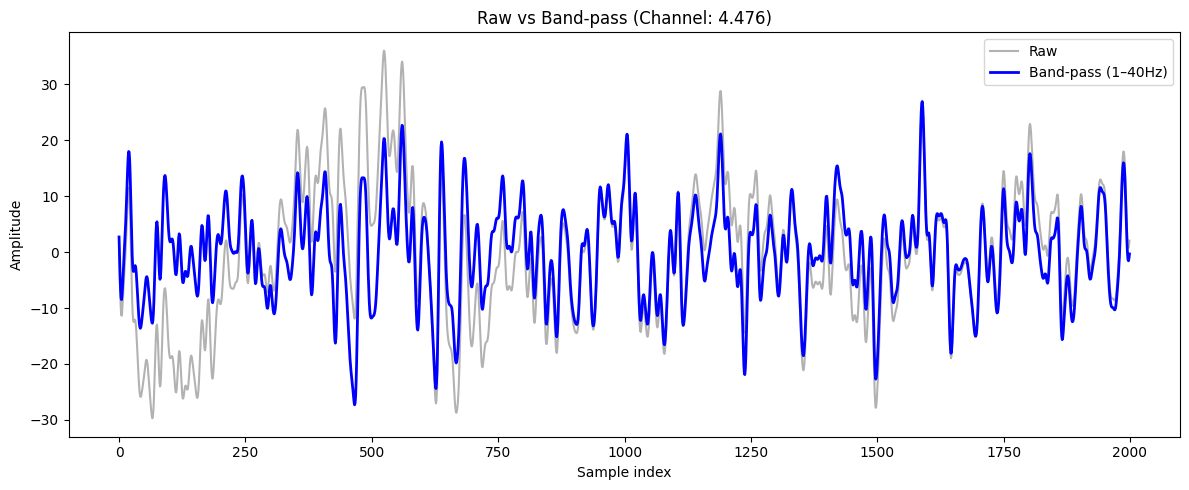

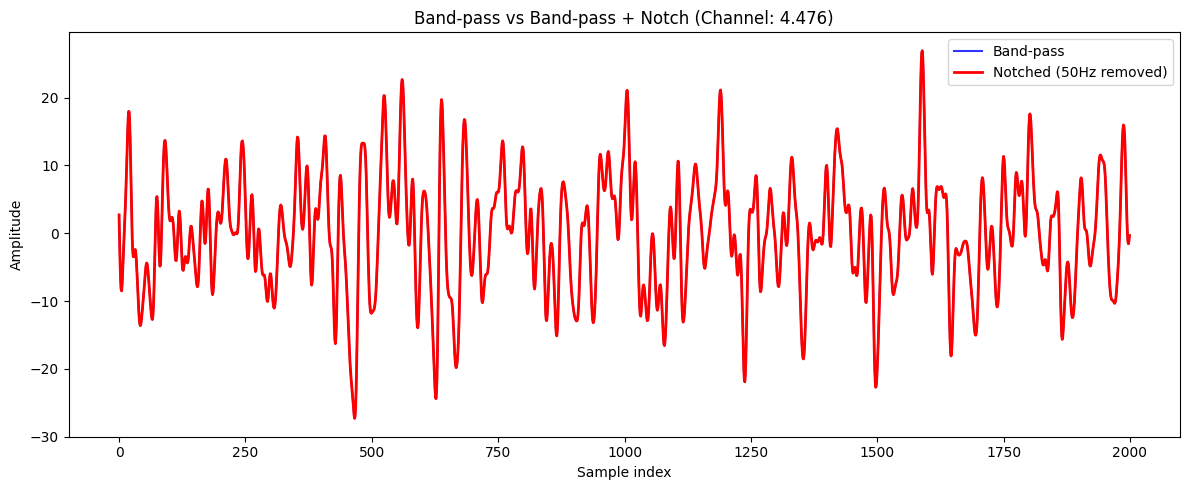

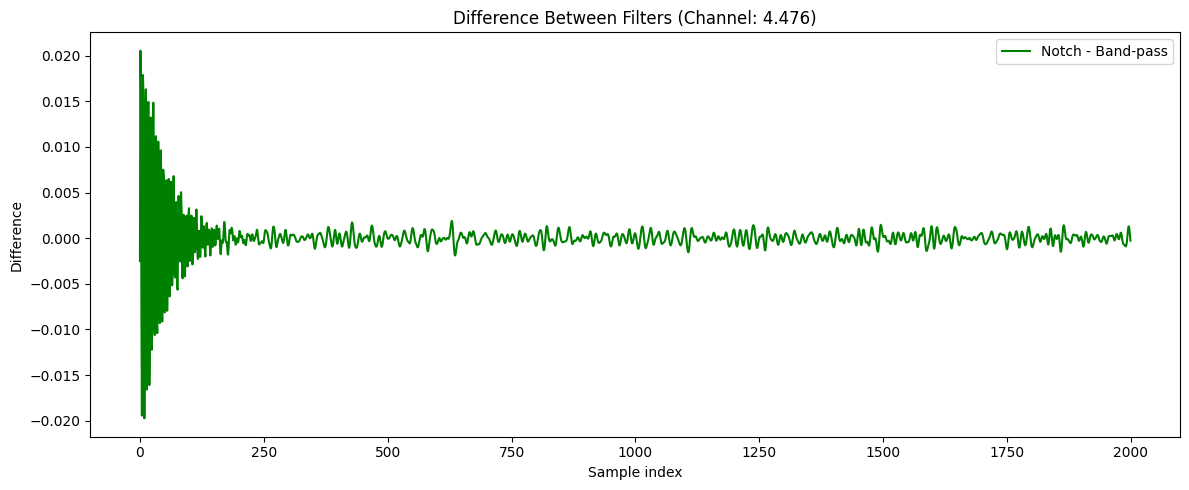

Window length (samples): 256
Number of windows: 121
Segmented EEG shape: (121, 256, 19)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch

# -----------------------------
# Configuration parameters
# -----------------------------
FS = 256
LOWCUT = 1.0
HIGHCUT = 40.0
NOTCH_FREQ = 50.0
Q_FACTOR = 30.0
WINDOW_SEC = 1.0

# -----------------------------
# Filter design functions
# -----------------------------
def bandpass_filter(data, fs, lowcut, highcut, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, data, axis=0)

def notch_filter(data, fs, freq, q):
    nyq = 0.5 * fs
    w0 = freq / nyq
    b, a = iirnotch(w0, q)
    return filtfilt(b, a, data, axis=0)

# -----------------------------
# Select one subject
# -----------------------------
subject_id = list(dataframes.keys())[0]
df = dataframes[subject_id]
channels = infer_channel_columns(df)
eeg = df[channels].values

print(f"Subject: {subject_id}")
print(f"EEG shape (samples × channels): {eeg.shape}")

# -----------------------------
# Apply filtering
# -----------------------------
eeg_bandpassed = bandpass_filter(eeg, FS, LOWCUT, HIGHCUT)
eeg_notched = notch_filter(eeg_bandpassed, FS, NOTCH_FREQ, Q_FACTOR)

# Difference between notch and band‑pass
eeg_diff = eeg_notched - eeg_bandpassed

# -----------------------------
# PLOTS
# -----------------------------
n_plot = min(2000, eeg.shape[0])
ch_idx = 0  # choose a channel to plot

# ---- 1) Raw vs Band-pass ----
plt.figure(figsize=(12, 5))
plt.plot(eeg[:n_plot, ch_idx], label="Raw", alpha=0.6, color="gray")
plt.plot(eeg_bandpassed[:n_plot, ch_idx], label="Band-pass (1–40Hz)", linewidth=2, color="blue")
plt.title(f"Raw vs Band-pass (Channel: {channels[ch_idx]})")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

# ---- 2) Band-pass vs Notch ----
plt.figure(figsize=(12, 5))
plt.plot(eeg_bandpassed[:n_plot, ch_idx], label="Band-pass", alpha=0.8, color="blue")
plt.plot(eeg_notched[:n_plot, ch_idx], label="Notched (50Hz removed)", linewidth=2, color="red")
plt.title(f"Band-pass vs Band-pass + Notch (Channel: {channels[ch_idx]})")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

# ---- 3) Difference (Notch - Band-pass) ----
plt.figure(figsize=(12, 5))
plt.plot(eeg_diff[:n_plot, ch_idx], label="Notch - Band-pass", color="green")
plt.title(f"Difference Between Filters (Channel: {channels[ch_idx]})")
plt.xlabel("Sample index")
plt.ylabel("Difference")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Segmentation
# -----------------------------
window_size = int(WINDOW_SEC * FS)
n_windows = eeg_notched.shape[0] // window_size

eeg_windows = eeg_notched[:n_windows * window_size].reshape(
    n_windows, window_size, eeg_notched.shape[1]
)

print(f"Window length (samples): {window_size}")
print(f"Number of windows: {n_windows}")
print(f"Segmented EEG shape: {eeg_windows.shape}")


Subject: s00
EEG shape (samples × channels): (30999, 19)


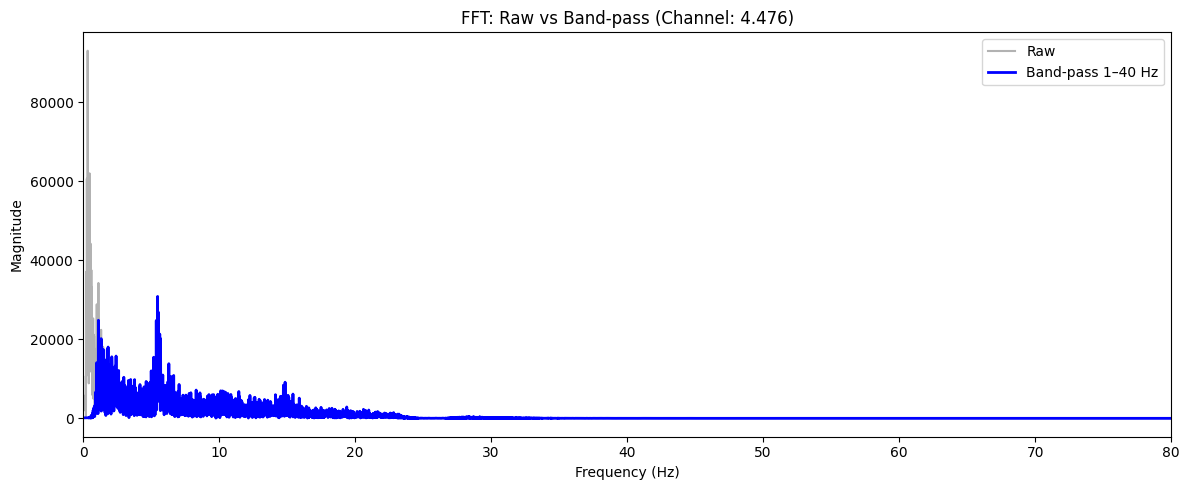

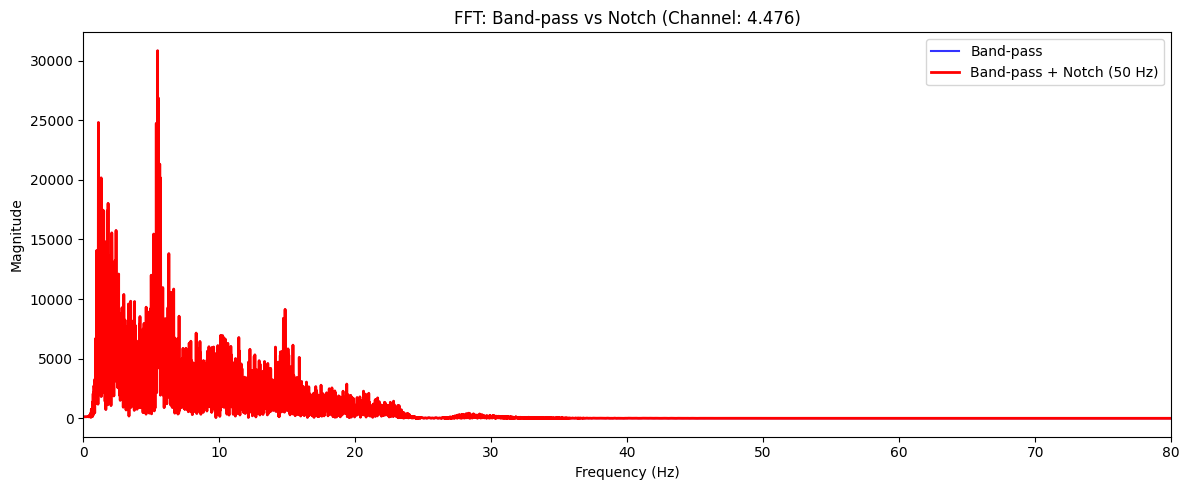

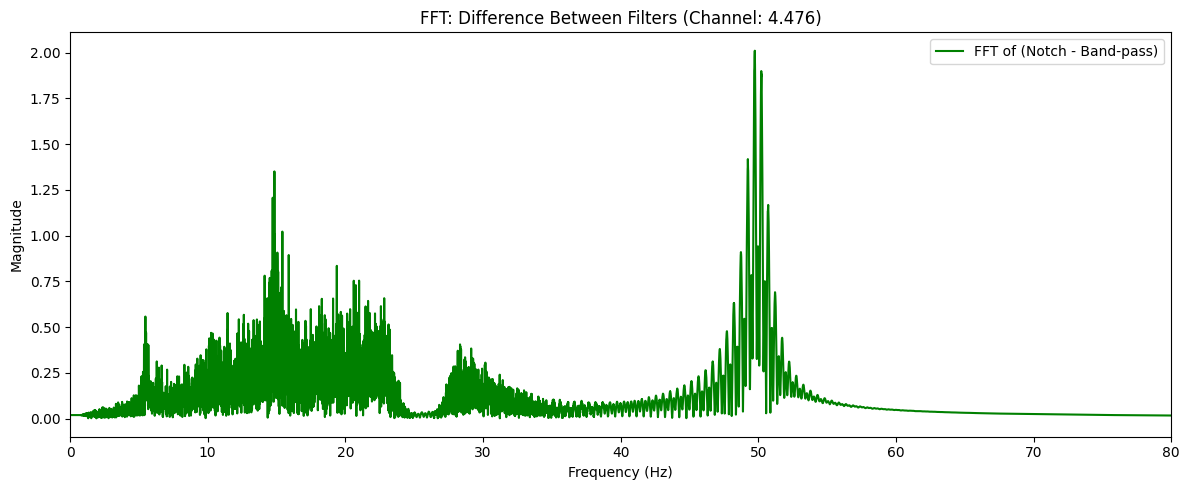

Window length (samples): 256
Number of windows: 121
Segmented EEG shape: (121, 256, 19)


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch

# -----------------------------
# Configuration parameters
# -----------------------------
FS = 256
LOWCUT = 1.0
HIGHCUT = 40.0
NOTCH_FREQ = 50.0
Q_FACTOR = 30.0
WINDOW_SEC = 1.0

# -----------------------------
# Filter design functions
# -----------------------------
def bandpass_filter(data, fs, lowcut, highcut, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, data, axis=0)

def notch_filter(data, fs, freq, q):
    nyq = 0.5 * fs
    w0 = freq / nyq
    b, a = iirnotch(w0, q)
    return filtfilt(b, a, data, axis=0)

# -----------------------------
# Helper: FFT function
# -----------------------------
def compute_fft(x, fs):
    N = len(x)
    freqs = np.fft.rfftfreq(N, 1/fs)
    fft_vals = np.abs(np.fft.rfft(x))
    return freqs, fft_vals

# -----------------------------
# Select one subject
# -----------------------------
subject_id = list(dataframes.keys())[0]
df = dataframes[subject_id]
channels = infer_channel_columns(df)
eeg = df[channels].values

print(f"Subject: {subject_id}")
print(f"EEG shape (samples × channels): {eeg.shape}")

# -----------------------------
# Apply filters
# -----------------------------
eeg_bandpassed = bandpass_filter(eeg, FS, LOWCUT, HIGHCUT)
eeg_notched = notch_filter(eeg_bandpassed, FS, NOTCH_FREQ, Q_FACTOR)

# Difference signal
eeg_diff = eeg_notched - eeg_bandpassed

# -----------------------------
# FFT PLOTS
# -----------------------------
ch_idx = 0  # choose the first EEG channel
signal_raw = eeg[:, ch_idx]
signal_bp = eeg_bandpassed[:, ch_idx]
signal_notch = eeg_notched[:, ch_idx]
signal_diff = eeg_diff[:, ch_idx]

# ---- 1) FFT: Raw vs Band-pass ----
freq_raw, fft_raw = compute_fft(signal_raw, FS)
freq_bp, fft_bp = compute_fft(signal_bp, FS)

plt.figure(figsize=(12,5))
plt.plot(freq_raw, fft_raw, label="Raw", alpha=0.6, color="gray")
plt.plot(freq_bp, fft_bp, label="Band-pass 1–40 Hz", linewidth=2, color="blue")
plt.title(f"FFT: Raw vs Band-pass (Channel: {channels[ch_idx]})")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 80)
plt.legend()
plt.tight_layout()
plt.show()

# ---- 2) FFT: Band-pass vs Notch ----
freq_notch, fft_notch = compute_fft(signal_notch, FS)

plt.figure(figsize=(12,5))
plt.plot(freq_bp, fft_bp, label="Band-pass", alpha=0.8, color="blue")
plt.plot(freq_notch, fft_notch, label="Band-pass + Notch (50 Hz)", linewidth=2, color="red")
plt.title(f"FFT: Band-pass vs Notch (Channel: {channels[ch_idx]})")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 80)
plt.legend()
plt.tight_layout()
plt.show()

# ---- 3) FFT: Difference (Notch - Band-pass) ----
freq_diff, fft_diff = compute_fft(signal_diff, FS)

plt.figure(figsize=(12,5))
plt.plot(freq_diff, fft_diff, label="FFT of (Notch - Band-pass)", color="green")
plt.title(f"FFT: Difference Between Filters (Channel: {channels[ch_idx]})")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 80)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Segmentation
# -----------------------------
window_size = int(WINDOW_SEC * FS)
n_windows = eeg_notched.shape[0] // window_size
eeg_windows = eeg_notched[:n_windows * window_size].reshape(
    n_windows, window_size, eeg_notched.shape[1]
)

print(f"Window length (samples): {window_size}")
print(f"Number of windows: {n_windows}")
print(f"Segmented EEG shape: {eeg_windows.shape}")

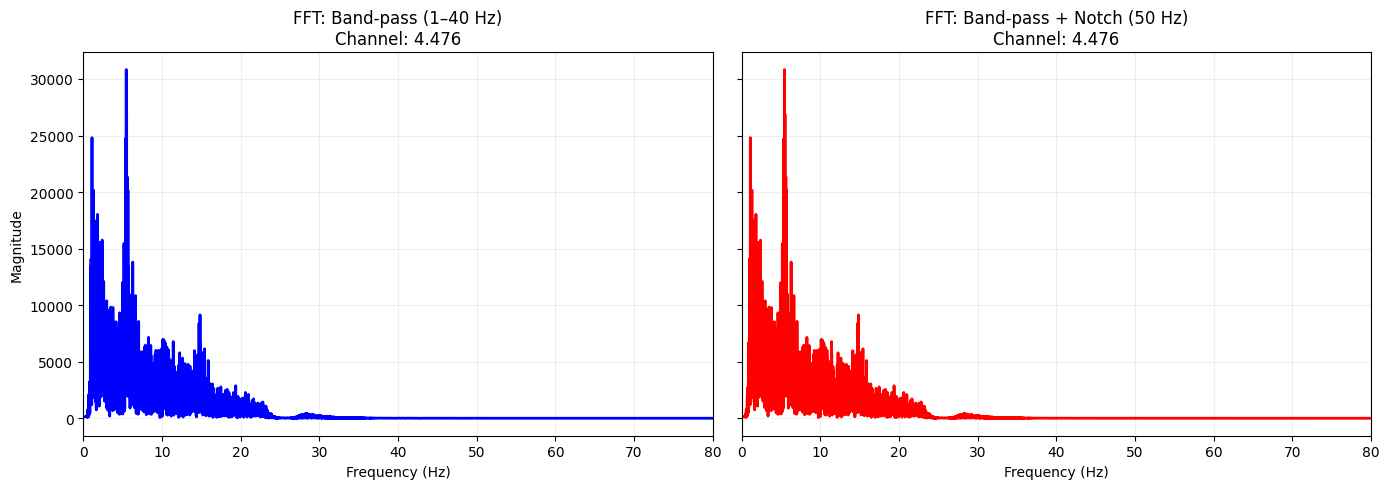

In [5]:
# ---- 2) FFT: Band-pass vs Notch (now using subplots) ----
freq_bp,   fft_bp   = compute_fft(signal_bp,    FS)
freq_notch, fft_notch = compute_fft(signal_notch, FS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left subplot: Band-pass only
axes[0].plot(freq_bp, fft_bp, color="blue", linewidth=2)
axes[0].set_title(f"FFT: Band-pass (1–40 Hz)\nChannel: {channels[ch_idx]}")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Magnitude")
axes[0].set_xlim(0, 80)
axes[0].grid(alpha=0.2)

# Right subplot: Band-pass + Notch
axes[1].plot(freq_notch, fft_notch, color="red", linewidth=2)
axes[1].set_title(f"FFT: Band-pass + Notch (50 Hz)\nChannel: {channels[ch_idx]}")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_xlim(0, 80)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Task 3 – Feature Extraction

In this task, you will compute informative features from each pre-processed EEG window produced in Task B. Feature extraction transforms raw windowed EEG signals into a compact representation suitable for machine learning. You will implement three common feature families:
* Time-domain features (summary statistics and Hjorth parameters)
* Frequency-domain features (band power derived from PSD)
* Time–frequency features (STFT-based summary features)
The outcome of this task is a feature matrix X with one row per window and one column per feature, ready for feature selection and classification.

In [6]:
import numpy as np
import pandas as pd
from scipy.signal import welch, stft

# -----------------------------
# Frequency band definitions
# -----------------------------
BANDS = {
    "delta": (0.5, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta":  (13.0, 30.0),
}

def hjorth_parameters(x: np.ndarray) -> tuple[float, float, float]:
    """
    Hjorth parameters for a 1D signal x:
    Activity   = var(x)
    Mobility   = sqrt(var(dx) / var(x))
    Complexity = mobility(dx) / mobility(x)
    """
    x = np.asarray(x)
    dx = np.diff(x)
    ddx = np.diff(dx)

    var_x = np.var(x)
    var_dx = np.var(dx) if dx.size else 0.0
    var_ddx = np.var(ddx) if ddx.size else 0.0

    activity = var_x
    mobility = np.sqrt(var_dx / var_x) if var_x > 0 else 0.0
    mobility_dx = np.sqrt(var_ddx / var_dx) if var_dx > 0 else 0.0
    complexity = (mobility_dx / mobility) if mobility > 0 else 0.0

    return activity, mobility, complexity

def bandpowers_from_psd(x: np.ndarray, fs: float, bands: dict) -> dict:
    """
    Compute band power by integrating PSD (Welch) within each band.
    Compatible with NumPy >= 2.0
    """
    f, pxx = welch(x, fs=fs, nperseg=min(256, len(x)))
    out = {}
    for name, (fmin, fmax) in bands.items():
        idx = np.logical_and(f >= fmin, f <= fmax)
        out[name] = np.trapezoid(pxx[idx], f[idx]) if np.any(idx) else 0.0
    return out


def stft_summary_features(x: np.ndarray, fs: float) -> dict:
    """
    Compute simple time–frequency summary statistics from STFT magnitude:
    - mean magnitude
    - std magnitude
    - max magnitude
    """
    f, t, Zxx = stft(x, fs=fs, nperseg=min(128, len(x)))
    mag = np.abs(Zxx)
    return {
        "stft_mag_mean": float(np.mean(mag)),
        "stft_mag_std": float(np.std(mag)),
        "stft_mag_max": float(np.max(mag)),
    }

# -----------------------------
# Feature extraction per window
# -----------------------------
def extract_features_for_window(window: np.ndarray, fs: float, channel_names: list[str]) -> dict:
    """
    window shape: (window_size, n_channels)
    Returns a flat dict of features for all channels.
    """
    feats = {}
    for ch_i, ch_name in enumerate(channel_names):
        x = window[:, ch_i]

        # Time-domain: mean, var, std
        feats[f"{ch_name}_mean"] = float(np.mean(x))
        feats[f"{ch_name}_var"] = float(np.var(x))
        feats[f"{ch_name}_std"] = float(np.std(x))

        # Hjorth
        act, mob, comp = hjorth_parameters(x)
        feats[f"{ch_name}_hjorth_activity"] = float(act)
        feats[f"{ch_name}_hjorth_mobility"] = float(mob)
        feats[f"{ch_name}_hjorth_complexity"] = float(comp)

        # Frequency-domain: band powers (Welch PSD)
        bp = bandpowers_from_psd(x, fs, BANDS)
        for band_name, power in bp.items():
            feats[f"{ch_name}_bp_{band_name}"] = float(power)

        # Time–frequency: STFT summary stats
        tf = stft_summary_features(x, fs)
        for k, v in tf.items():
            feats[f"{ch_name}_{k}"] = float(v)

    return feats

# Extract features for all windows
feature_rows = []
for w in range(eeg_windows.shape[0]):
    feature_rows.append(extract_features_for_window(eeg_windows[w], FS, channels))

features_df = pd.DataFrame(feature_rows)
print("Feature matrix shape (windows × features):", features_df.shape)
display(features_df.head())


Feature matrix shape (windows × features): (121, 247)


,4.476_mean,4.476_var,4.476_std,4.476_hjorth_activity,4.476_hjorth_mobility,4.476_hjorth_complexity,4.476_bp_delta,4.476_bp_theta,4.476_bp_alpha,4.476_bp_beta,...,0.84831_hjorth_activity,0.84831_hjorth_mobility,0.84831_hjorth_complexity,0.84831_bp_delta,0.84831_bp_theta,0.84831_bp_alpha,0.84831_bp_beta,0.84831_stft_mag_mean,0.84831_stft_mag_std,0.84831_stft_mag_max
0,0.076145,45.052879,6.712144,45.052879,0.215086,1.632197,10.517274,5.088664,4.404954,6.857609,...,33.334061,0.152596,2.026810,16.302266,7.954006,4.202113,1.345069,0.212547,0.527705,3.668022
1,-1.830939,83.533270,9.139654,83.533270,0.173804,1.722637,18.177077,26.716194,7.930568,7.814944,...,49.627044,0.176852,1.800303,13.663184,9.823624,9.881461,4.243716,0.284375,0.651627,4.602519
2,1.268391,108.577601,10.420058,108.577601,0.182103,1.482840,15.795820,82.680475,33.171180,8.460330,...,75.424066,0.177265,1.487813,9.217258,49.204316,13.020675,2.835724,0.295396,0.739302,5.930671
3,1.409698,62.735450,7.920571,62.735450,0.175525,1.828493,13.259983,30.787489,10.547895,3.693733,...,61.522775,0.144032,2.217982,20.546032,10.146825,4.439796,4.654017,0.303585,0.737042,6.279068
4,-1.511593,67.991929,8.245722,67.991929,0.183766,1.768836,19.114922,28.401796,4.984031,5.211800,...,31.208210,0.196923,1.612637,21.867336,8.396897,4.079617,2.721636,0.215103,0.501856,3.390514


## Task 4 – Feature Selection

In this task, you will reduce the feature space produced in Task C and quantify the effect on classification performance. EEG feature sets are often high dimensional and redundant; feature selection reduces overfitting risk, improves generalisation, and lowers computation. You will implement three standard approaches:
* Filter method: mutual information ranking (fast, classifier-independent)
* Wrapper method: recursive feature elimination (optimises a chosen classifier)
* Embedded method: Random Forest feature importance (selection occurs via the model)

You will compare model performance using:
(1) all features vs 
(2) selected features.

In [7]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, balanced_accuracy_score

from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# 0) Define y (target) for Task B "single subject" windowing
# -----------------------------
# Task B (as you kept it) segments ONE subject into windows:
#   subject_id = list(dataframes.keys())[0]
#   eeg_windows = ...
#
# Therefore, the only consistent supervised target you can define WITHOUT
# reworking Task B is a pseudo-label derived from the signal itself.
#
# Recommended for demonstrating feature selection mechanics:
# Binary label based on high vs low alpha-band power (median split)
#
# Note: This is not a "BCI class" label; it is a proxy target to allow the
# feature selection pipelines to run end-to-end.

from scipy.signal import welch

if "y" not in globals():
    if "eeg_windows" not in globals():
        raise ValueError("eeg_windows not found. Run Task B windowing before Task D.")
    if "FS" not in globals():
        raise ValueError("FS not found. Define FS (sampling frequency) as in Task B.")

    # Compute per-window alpha power averaged across channels
    alpha_lo, alpha_hi = 8.0, 13.0
    alpha_powers = []

    for w in range(eeg_windows.shape[0]):
        win = eeg_windows[w]  # shape: (window_size, n_channels)
        ch_p = []
        for ch in range(win.shape[1]):
            f, pxx = welch(win[:, ch], fs=FS, nperseg=min(256, win.shape[0]))
            idx = (f >= alpha_lo) & (f <= alpha_hi)
            # NumPy >=2.0 uses trapezoid
            bp = np.trapezoid(pxx[idx], f[idx]) if np.any(idx) else 0.0
            ch_p.append(bp)
        alpha_powers.append(np.mean(ch_p))

    alpha_powers = np.asarray(alpha_powers)
    thr = np.median(alpha_powers)
    y = (alpha_powers > thr).astype(int)  # 0/1 labels

    print("y created as proxy label: high vs low alpha power (median split)")
    print("Class balance:", np.bincount(y))

# -----------------------------
# Continue with your original Task D code
# -----------------------------
X = features_df.values
feature_names = features_df.columns.to_list()

bal_acc = make_scorer(balanced_accuracy_score)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(X_in, y_in, estimator, cv):
    scores = cross_val_score(estimator, X_in, y_in, cv=cv, scoring=bal_acc, n_jobs=-1)
    return float(scores.mean()), float(scores.std())

baseline_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, n_jobs=-1))
])

base_mean, base_std = evaluate_model(X, y, baseline_clf, cv)
print(f"Baseline (all features) balanced accuracy: {base_mean:.3f} ± {base_std:.3f}")

# 1) FILTER METHOD: Mutual Information ranking (SelectKBest)
k = min(200, X.shape[1])
filter_selector = SelectKBest(score_func=mutual_info_classif, k=k)

filter_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("select", filter_selector),
    ("clf", LogisticRegression(max_iter=2000, n_jobs=-1))
])

f_mean, f_std = evaluate_model(X, y, filter_clf, cv)
print(f"Filter (MI top-{k}) balanced accuracy: {f_mean:.3f} ± {f_std:.3f}")

filter_selector.fit(StandardScaler().fit_transform(X), y)
mask = filter_selector.get_support()
selected_filter_features = [n for n, m in zip(feature_names, mask) if m]
print(f"Filter selected features: {len(selected_filter_features)}")

# 2) WRAPPER METHOD: RFE
n_select = min(50, X.shape[1])

rfe_estimator = LogisticRegression(max_iter=2000, n_jobs=-1)
wrapper_selector = RFE(estimator=rfe_estimator, n_features_to_select=n_select, step=0.1)

wrapper_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("select", wrapper_selector),
    ("clf", LogisticRegression(max_iter=2000, n_jobs=-1))
])

w_mean, w_std = evaluate_model(X, y, wrapper_clf, cv)
print(f"Wrapper (RFE {n_select}) balanced accuracy: {w_mean:.3f} ± {w_std:.3f}")

wrapper_selector.fit(StandardScaler().fit_transform(X), y)
mask = wrapper_selector.get_support()
selected_wrapper_features = [n for n, m in zip(feature_names, mask) if m]
print(f"Wrapper selected features: {len(selected_wrapper_features)}")

# 3) EMBEDDED METHOD: Random Forest importance (top-k)
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

X_scaled = StandardScaler().fit_transform(X)
rf.fit(X_scaled, y)

importances = rf.feature_importances_
top_k = min(100, len(importances))
top_idx = np.argsort(importances)[::-1][:top_k]

X_rf = X[:, top_idx]

rf_eval_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, n_jobs=-1))
])

e_mean, e_std = evaluate_model(X_rf, y, rf_eval_clf, cv)
print(f"Embedded (RF importance top-{top_k}) balanced accuracy: {e_mean:.3f} ± {e_std:.3f}")

results = pd.DataFrame([
    {"method": "All features", "n_features": X.shape[1], "bal_acc_mean": base_mean, "bal_acc_std": base_std},
    {"method": f"Filter (MI top-{k})", "n_features": k, "bal_acc_mean": f_mean, "bal_acc_std": f_std},
    {"method": f"Wrapper (RFE {n_select})", "n_features": n_select, "bal_acc_mean": w_mean, "bal_acc_std": w_std},
    {"method": f"Embedded (RF top-{top_k})", "n_features": top_k, "bal_acc_mean": e_mean, "bal_acc_std": e_std},
]).sort_values("bal_acc_mean", ascending=False)

display(results)


y created as proxy label: high vs low alpha power (median split)
Class balance: [61 60]


/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(m

Baseline (all features) balanced accuracy: 0.867 ± 0.049


/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(m

Filter (MI top-200) balanced accuracy: 0.859 ± 0.034
Filter selected features: 200


...

Wrapper (RFE 50) balanced accuracy: 0.868 ± 0.049
Wrapper selected features: 50


/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(m

Embedded (RF importance top-100) balanced accuracy: 0.951 ± 0.017


/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(m

,method,n_features,bal_acc_mean,bal_acc_std
3,Embedded (RF top-100),100,0.950641,0.017032
2,Wrapper (RFE 50),50,0.867949,0.048878
0,All features,247,0.867308,0.049263
1,Filter (MI top-200),200,0.858974,0.034461


# Task 5: Classification

In this task, you will train and compare at least two classifiers on the feature matrix produced in Task 3. The goal is to evaluate how model choice interacts with EEG feature representations and feature selection. You will compare:

* A linear baseline classifier (LDA or Logistic Regression)
An ensemble classifier (Random Forest)

Performance will be estimated using k-fold cross-validation. Evaluation will include:

Balanced accuracy (robust to class imbalance)

Confusion matrix (class-wise error structure)

Students should report which model performs best under which feature set (all features vs selected features), and give a short explanation grounded in bias–variance and noise robustness.

Learning outcomes

Train baseline and ensemble models for EEG feature classification.

Use cross-validation correctly for performance estimation.

Interpret balanced accuracy and confusion matrices to compare models.

Available feature sets: ['All features', 'RF top-k features']


<Figure size 600x600 with 0 Axes>

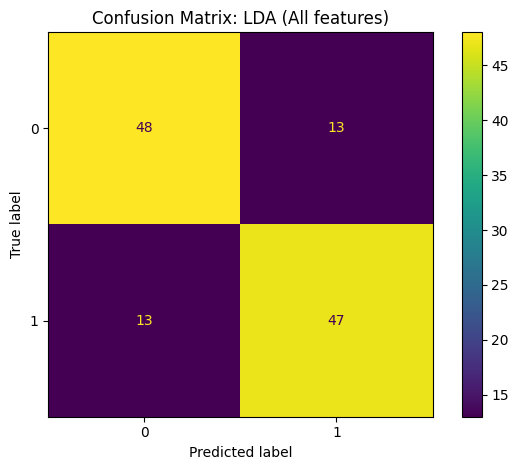

/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(m

<Figure size 600x600 with 0 Axes>

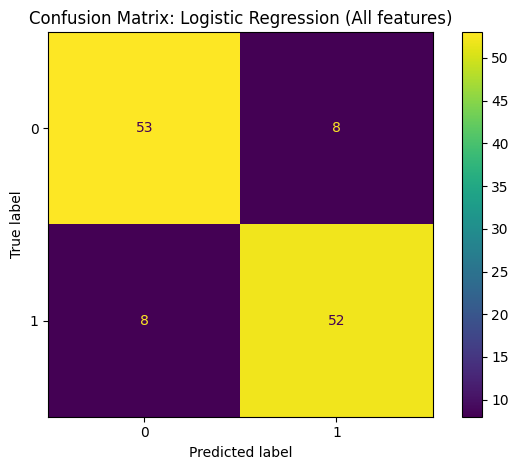

<Figure size 600x600 with 0 Axes>

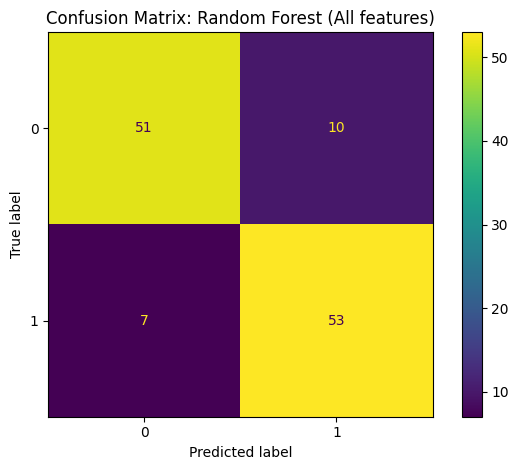

<Figure size 600x600 with 0 Axes>

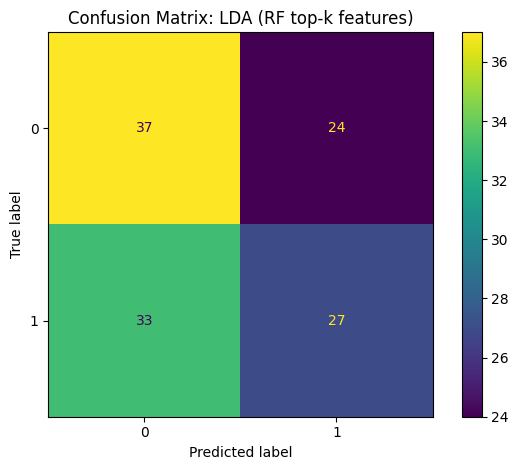

/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/root/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(m

<Figure size 600x600 with 0 Axes>

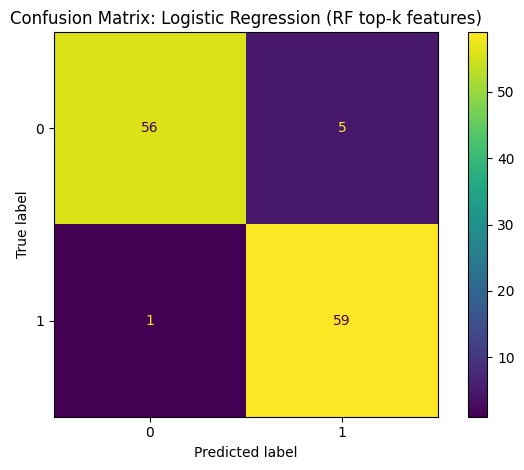

<Figure size 600x600 with 0 Axes>

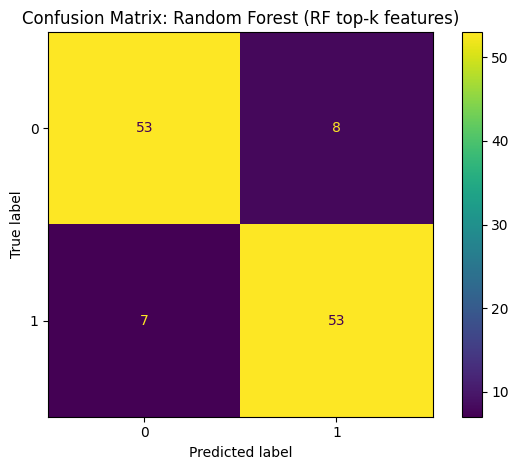

,feature_set,model,balanced_accuracy
1,All features,Logistic Regression,0.867760
2,All features,Random Forest,0.859699
0,All features,LDA,0.785109
4,RF top-k features,Logistic Regression,0.950683
5,RF top-k features,Random Forest,0.876093
3,RF top-k features,LDA,0.528279


In [8]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# -----------------------------
# 1) Prepare feature sets
# -----------------------------
X_all = features_df.values
feature_sets = {
    "All features": X_all
}

# If you created a reduced feature set in Task D, add it here.
# Example A: RF importance top-k (top_idx exists from Task D)
if "top_idx" in globals():
    feature_sets["RF top-k features"] = X_all[:, top_idx]

# Example B: MI top-k (mask exists if you stored it)
# if "mask" in globals():
#     feature_sets["MI selected features"] = X_all[:, mask]

print("Available feature sets:", list(feature_sets.keys()))

# -----------------------------
# 2) Define models
# -----------------------------
models = {
    "LDA": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearDiscriminantAnalysis())
    ]),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, n_jobs=-1))
    ]),
    "Random Forest": Pipeline([
        ("clf", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ])
}

# -----------------------------
# 3) Cross-validation configuration
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# 4) Run evaluation: balanced accuracy + confusion matrix
# -----------------------------
results = []

for fs_name, X in feature_sets.items():
    for model_name, model in models.items():

        # Cross-validated predictions for confusion matrix
        y_pred = cross_val_predict(model, X, y, cv=cv, n_jobs=-1)

        # Balanced accuracy
        bal_acc = balanced_accuracy_score(y, y_pred)

        results.append({
            "feature_set": fs_name,
            "model": model_name,
            "balanced_accuracy": bal_acc
        })

        # Confusion matrix plot
        cm = confusion_matrix(y, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)

        plt.figure(figsize=(6, 6))
        disp.plot(values_format="d")
        plt.title(f"Confusion Matrix: {model_name} ({fs_name})")
        plt.tight_layout()
        plt.show()

results_df = pd.DataFrame(results).sort_values(["feature_set", "balanced_accuracy"], ascending=[True, False])
display(results_df)


# Apply your knowledge
## Task 6 – Cross-Subject Generalisation and Domain Shift

EEG models often perform well on data from a single subject but fail to generalise across users due to anatomical and physiological differences. In this task, you will evaluate cross-subject generalisation by training models on a subset of subjects and testing on unseen subjects.

Implement the following:
* Construct training and test sets based on subject identity, not random windows
* Train a classifier using pooled data from multiple subjects
* Evaluate performance on held-out subjects
* Compare results against within-subject cross-validation

This task highlights domain shift and generalisation challenges in real BCI systems.
You should:
* Modify segmentation to retain subject_id per window
* Use leave-one-subject-out (LOSO) evaluation:
* Train on all subjects except one
* Test on the held-out subject

Repeat for several subjects and report:
* Balanced accuracy per subject
* Mean and variance across subjects
* Compare with standard k-fold CV results

In [9]:
# === Imports ===
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.signal import butter, filtfilt, iirnotch, welch, stft

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ==========================================
# Config (match your Task 2 settings)
# ==========================================
FS = 256
LOWCUT, HIGHCUT = 1.0, 40.0
NOTCH_FREQ, Q_FACTOR = 50.0, 30.0
WINDOW_SEC = 1.0
WINDOW_SIZE = int(WINDOW_SEC * FS)

# ==========================================
# Helpers: channel pick, filters, windowing
# ==========================================
def infer_channel_columns(df: pd.DataFrame) -> list[str]:
    """Heuristic: use numeric columns as EEG channels; drop typical metadata if present."""
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    exclude = {"time", "timestamp", "ts", "label", "class", "event", "subject", "id"}
    return [c for c in num_cols if c.strip().lower() not in exclude]

def bandpass_filter(data: np.ndarray, fs: float, low: float, high: float, order=4) -> np.ndarray:
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, data, axis=0)

def notch_filter(data: np.ndarray, fs: float, freq: float, q: float) -> np.ndarray:
    nyq = 0.5 * fs
    w0 = freq / nyq
    b, a = iirnotch(w0, q)
    return filtfilt(b, a, data, axis=0)

def segment_windows(X: np.ndarray, window_size: int) -> np.ndarray:
    """(samples, channels) -> (n_windows, window_size, channels). Drops remainder."""
    n = X.shape[0] // window_size
    if n == 0:
        return np.empty((0, window_size, X.shape[1]))
    Xc = X[:n*window_size]
    return Xc.reshape(n, window_size, X.shape[1])

# ==========================================
# Task 3 feature functions (simplified)
# ==========================================
BANDS = {"delta": (0.5, 4.0), "theta": (4.0, 8.0), "alpha": (8.0, 13.0), "beta": (13.0, 30.0)}

def hjorth_parameters(x: np.ndarray) -> tuple[float, float, float]:
    x = np.asarray(x)
    dx = np.diff(x)
    ddx = np.diff(dx)
    var_x = np.var(x)
    var_dx = np.var(dx) if dx.size else 0.0
    var_ddx = np.var(ddx) if ddx.size else 0.0
    activity = var_x
    mobility = np.sqrt(var_dx / var_x) if var_x > 0 else 0.0
    mobility_dx = np.sqrt(var_ddx / var_dx) if var_dx > 0 else 0.0
    complexity = (mobility_dx / mobility) if mobility > 0 else 0.0
    return activity, mobility, complexity

def bandpowers_from_psd(x: np.ndarray, fs: float, bands: dict) -> dict:
    f, pxx = welch(x, fs=fs, nperseg=min(256, len(x)))
    out = {}
    for name, (fmin, fmax) in bands.items():
        idx = (f >= fmin) & (f <= fmax)
        out[name] = np.trapezoid(pxx[idx], f[idx]) if np.any(idx) else 0.0
    return out

def stft_summary_features(x: np.ndarray, fs: float) -> dict:
    f, t, Zxx = stft(x, fs=fs, nperseg=min(128, len(x)))
    mag = np.abs(Zxx)
    return {
        "stft_mag_mean": float(np.mean(mag)),
        "stft_mag_std":  float(np.std(mag)),
        "stft_mag_max":  float(np.max(mag)),
    }

def extract_features_for_window(window: np.ndarray, fs: float, channel_names: list[str]) -> dict:
    feats = {}
    for ch_i, ch_name in enumerate(channel_names):
        x = window[:, ch_i]

        # Time domain
        feats[f"{ch_name}_mean"] = float(np.mean(x))
        feats[f"{ch_name}_var"]  = float(np.var(x))
        feats[f"{ch_name}_std"]  = float(np.std(x))

        # Hjorth
        act, mob, comp = hjorth_parameters(x)
        feats[f"{ch_name}_hjorth_activity"]   = float(act)
        feats[f"{ch_name}_hjorth_mobility"]   = float(mob)
        feats[f"{ch_name}_hjorth_complexity"] = float(comp)

        # Frequency domain
        for band, p in bandpowers_from_psd(x, fs, BANDS).items():
            feats[f"{ch_name}_bp_{band}"] = float(p)

        # Time–frequency
        for k, v in stft_summary_features(x, fs).items():
            feats[f"{ch_name}_{k}"] = float(v)

    return feats

# ==========================================
# Build subject-aware dataset (windows + subject_id)
# Expects: `dataframes` dict[str->pd.DataFrame] already loaded (Task 1)
# ==========================================
def build_subject_window_bank(dataframes: dict[str, pd.DataFrame]) -> tuple[list[np.ndarray], list[str], list[list[str]]]:
    """
    Returns:
      all_windows: list of (n_w, window_size, n_ch) arrays per subject (keeps order)
      subjects:    parallel list of subject_ids per subject block
      channel_lists: list of channel-name lists per subject (schema may vary)
    """
    all_windows, subjects, channel_lists = [], [], []
    for subject_id, df in sorted(dataframes.items()):
        ch = infer_channel_columns(df)
        if not ch:
            continue
        X = df[ch].values
        # Task 2 pre-processing
        X = bandpass_filter(X, FS, LOWCUT, HIGHCUT)
        X = notch_filter(X, FS, NOTCH_FREQ, Q_FACTOR)
        # Windowing
        W = segment_windows(X, WINDOW_SIZE)
        if W.shape[0] == 0:
            continue
        all_windows.append(W)
        subjects.append(subject_id)
        channel_lists.append(ch)
    return all_windows, subjects, channel_lists

# ==========================================
# Flatten windows across subjects + remember subject_id per window
# ==========================================
def stack_windows_with_ids(all_windows: list[np.ndarray], subjects: list[str]) -> tuple[np.ndarray, np.ndarray]:
    """
    Returns:
      W_all: (N, window_size, n_ch)   # assumes consistent n_ch across subjects
      subj_ids: (N,) array of subject_id (str) for each window
    """
    # Check consistent channel count
    n_chs = {W.shape[2] for W in all_windows}
    if len(n_chs) != 1:
        raise ValueError(f"Inconsistent channel counts across subjects: {n_chs}. "
                         "Ensure same channel schema or harmonise columns first.")
    W_all = np.concatenate(all_windows, axis=0)
    subj_ids = np.concatenate([np.array([sid]*W.shape[0], dtype=object) for W, sid in zip(all_windows, subjects)])
    return W_all, subj_ids

# ==========================================
# Feature extraction for all windows (single shared channel list)
# ==========================================
def extract_features_all_windows(W_all: np.ndarray, channel_names: list[str]) -> pd.DataFrame:
    rows = [extract_features_for_window(W_all[i], FS, channel_names) for i in range(W_all.shape[0])]
    return pd.DataFrame(rows)

# ==========================================
# Proxy label: high vs low alpha power (no leakage)
# ==========================================
def alpha_power_per_window(W: np.ndarray, fs: float) -> np.ndarray:
    """Average alpha (8–13Hz) power across channels for each window."""
    alpha_lo, alpha_hi = 8.0, 13.0
    alpha_vals = []
    for i in range(W.shape[0]):
        win = W[i]  # (T, C)
        ch_p = []
        for c in range(win.shape[1]):
            f, pxx = welch(win[:, c], fs=fs, nperseg=min(256, win.shape[0]))
            idx = (f >= alpha_lo) & (f <= alpha_hi)
            bp = np.trapezoid(pxx[idx], f[idx]) if np.any(idx) else 0.0
            ch_p.append(bp)
        alpha_vals.append(np.mean(ch_p))
    return np.asarray(alpha_vals)

def make_proxy_labels_LOSO(W_all: np.ndarray, subj_ids: np.ndarray, train_mask: np.ndarray) -> tuple[np.ndarray, float]:
    """
    Compute binary labels using ONLY training windows to set the threshold.
    Returns:
      y (N,), threshold_used
    """
    alpha_vals = alpha_power_per_window(W_all, FS)
    thr = np.median(alpha_vals[train_mask])  # threshold from TRAIN ONLY
    y = (alpha_vals > thr).astype(int)
    return y, float(thr)

# ==========================================
# LOSO evaluation
# ==========================================
def loso_eval(features_df: pd.DataFrame, subj_ids: np.ndarray, W_all: np.ndarray) -> pd.DataFrame:
    unique_subj = np.unique(subj_ids)
    results = []

    X_all = features_df.values
    feature_names = list(features_df.columns)

    for test_sid in unique_subj:
        test_mask  = (subj_ids == test_sid)
        train_mask = ~test_mask

        # Proxy labels (replace with real labels if available)
        y_all, thr = make_proxy_labels_LOSO(W_all, subj_ids, train_mask)

        X_train, y_train = X_all[train_mask], y_all[train_mask]
        X_test,  y_test  = X_all[test_mask],  y_all[test_mask]

        # Simple, robust baseline (as used in the lab tasks)
        clf = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, solver="lbfgs"))
        ])
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        bal_acc = balanced_accuracy_score(y_test, y_pred)

        results.append({
            "subject": test_sid,
            "n_test_windows": int(test_mask.sum()),
            "balanced_accuracy": float(bal_acc),
            "alpha_thr_train": thr
        })

    return pd.DataFrame(results).sort_values("subject")

# ==========================================
# Pooled (subject-ignorant) k-fold baseline
# ==========================================
def pooled_kfold_baseline(features_df: pd.DataFrame, W_all: np.ndarray, k: int = 5) -> tuple[float, float]:
    # Create proxy labels with threshold from ALL data (pooled) for this baseline
    alpha_vals = alpha_power_per_window(W_all, FS)
    thr = np.median(alpha_vals)
    y = (alpha_vals > thr).astype(int)

    X = features_df.values
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, solver="lbfgs"))
    ])
    scores = cross_val_score(clf, X, y, cv=cv, scoring="balanced_accuracy")
    return float(scores.mean()), float(scores.var())

In [10]:
# 1) Build subject windows (keeps subject_id per window)
all_windows, subjects, channel_lists = build_subject_window_bank(dataframes)

# If schemas differ across subjects, harmonise first (e.g., enforce the same 19 standard 10–20 channels).
# Here we assume identical channel names/order across subjects:
channel_names = channel_lists[0]  # use first subject's channel set

# 2) Stack windows and subject IDs
W_all, subj_ids = stack_windows_with_ids(all_windows, subjects)
print("All windows:", W_all.shape, "Unique subjects:", np.unique(subj_ids).size)

# 3) Extract features for ALL windows
features_df = extract_features_all_windows(W_all, channel_names)
print("Feature matrix:", features_df.shape)

# 4) LOSO eval
loso_df = loso_eval(features_df, subj_ids, W_all)
display(loso_df)

# 5) Summary stats across subjects
mean_bal = loso_df["balanced_accuracy"].mean()
var_bal  = loso_df["balanced_accuracy"].var()
print(f"LOSO mean balanced accuracy: {mean_bal:.3f}")
print(f"LOSO variance: {var_bal:.4f}")

# 6) Pooled k-fold (subject-ignorant) baseline
pooled_mean, pooled_var = pooled_kfold_baseline(features_df, W_all, k=5)
print(f"Pooled (k-fold) mean balanced accuracy: {pooled_mean:.3f}")
print(f"Pooled variance: {pooled_var:.4f}")

All windows: (4356, 256, 19) Unique subjects: 36
Feature matrix: (4356, 247)


/root/.env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


,subject,n_test_windows,balanced_accuracy,alpha_thr_train
0,s00,121,1.000000,4.961983
1,s01,121,1.000000,4.973352
2,s02,121,0.900000,4.960546
3,s03,121,1.000000,5.176836
4,s04,121,1.000000,4.960546
5,s05,121,0.992647,5.055414
6,s06,121,1.000000,5.178454
7,s07,121,0.967105,5.112033
8,s08,121,0.995763,5.206135
9,s09,121,0.937500,5.187025


LOSO mean balanced accuracy: 0.976
LOSO variance: 0.0008
Pooled (k-fold) mean balanced accuracy: 0.984
Pooled variance: 0.0000


## Task 7 – Feature Stability and Model Robustness Analysis

High accuracy alone is insufficient for EEG systems; features and models must be stable and robust to noise, window length, and random variation. In this task, you will analyse feature stability and model robustness under controlled perturbations.

You will:
* Evaluate how feature rankings change across cross-validation folds
* Test classifier sensitivity to:
* Window length (e.g. 0.5 s, 1 s, 2 s)
* Added synthetic noise
* Compare robustness of linear vs ensemble models

### You should:
* Repeat feature selection (MI or RF importance) across CV folds
* Measure feature rank stability using:
* Rank correlation
* Overlap of top-k features
* Re-run classification with:
* Different window lengths
* Added Gaussian noise at controlled SNR levels

### Compare robustness of:
* Logistic Regression / LDA
* Random Forest